In [ ]:
!pip install tensorflow opencv-python matplotlib seaborn

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
import os

os.makedirs(dataset_path + "/val", exist_ok=True)
os.makedirs(dataset_path + "/test", exist_ok=True)

In [ ]:
classes = ['Open', 'Closed', 'yawn', 'no_yawn']

In [ ]:
import random
import shutil

for c in classes:
    path = dataset_path + "/train/" + c
    images = os.listdir(path)

    random.shuffle(images)

    val_size = int(0.15 * len(images))
    test_size = int(0.15 * len(images))

    val_images = images[:val_size]
    test_images = images[val_size:val_size+test_size]

    for img in val_images:
        shutil.move(path + "/" + img, dataset_path + "/val/" + c + "/" + img)

    for img in test_images:
        shutil.move(path + "/" + img, dataset_path + "/test/" + c + "/" + img)

In [ ]:
os.listdir(dataset_path)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_path = dataset_path + "/train"
val_path = dataset_path + "/val"
test_path = dataset_path + "/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

In [ ]:
print(train_data.class_indices)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_cnn = Sequential([

    # Layer 1
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    # Layer 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Layer 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Flatten
    Flatten(),

    # Fully Connected
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output layer (4 classes)
    Dense(4, activation='softmax')
])

In [ ]:
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model_cnn.summary()

In [ ]:
history_cnn = model_cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

In [ ]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

In [ ]:
base_model.trainable = False

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(4, activation='softmax')(x)

model_mobilenet = Model(inputs=base_model.input, outputs=output)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
dataset_path = "/content/drive/MyDrive/Driver_Drowsiness"

In [3]:
import os
os.listdir(dataset_path)

['train', 'val', 'test']

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_path = dataset_path + "/train"
val_path = dataset_path + "/val"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [5]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 1428 images belonging to 4 classes.
Found 736 images belonging to 4 classes.


In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(4, activation='softmax')(x)

model_mobilenet = Model(inputs=base_model.input, outputs=output)

In [8]:
model_mobilenet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history_mobilenet = model_mobilenet.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 285s 6s/step - accuracy: 0.7703 - loss: 0.4391 - val_accuracy: 0.8111 - val_loss: 0.3901
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.8445 - loss: 0.2957 - val_accuracy: 0.8546 - val_loss: 0.2947
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step - accuracy: 0.8739 - loss: 0.2608 - val_accuracy: 0.8804 - val_loss: 0.2677
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.8838 - loss: 0.2343 - val_accuracy: 0.8804 - val_loss: 0.2727
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step - accuracy: 0.8978 - loss: 0.2062 - val_accuracy: 0.8899 - val_loss: 0.2381


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

In [15]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Define dataset path
dataset_path = "/content/drive/MyDrive/Driver_Drowsiness"

# Define paths
train_path = dataset_path + "/train"
val_path = dataset_path + "/val"
test_path = dataset_path + "/test"

# Import
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 1428 images belonging to 4 classes.
Found 736 images belonging to 4 classes.
Found 736 images belonging to 4 classes.


In [16]:
test_loss, test_acc = model_mobilenet.evaluate(test_data)

print("Test Accuracy:", test_acc)

23/23 ━━━━━━━━━━━━━━━━━━━━ 152s 7s/step - accuracy: 0.8913 - loss: 0.2273
Test Accuracy: 0.8913043737411499


In [17]:
import numpy as np

y_pred = model_mobilenet.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_data.classes

23/23 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step


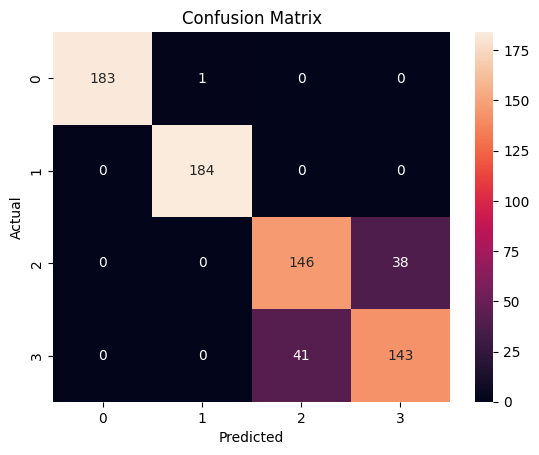

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=test_data.class_indices.keys()
))

              precision    recall  f1-score   support

      Closed       1.00      0.99      1.00       184
        Open       0.99      1.00      1.00       184
     no_yawn       0.78      0.79      0.79       184
        yawn       0.79      0.78      0.78       184

    accuracy                           0.89       736
   macro avg       0.89      0.89      0.89       736
weighted avg       0.89      0.89      0.89       736



In [20]:
def fatigue_level(label):
    if label in ['Open', 'no_yawn']:
        return 0
    elif label == 'yawn':
        return 1
    elif label == 'Closed':
        return 2

In [21]:
class_labels = list(test_data.class_indices.keys())

pred_labels = [class_labels[i] for i in y_pred_classes]

fatigue_predictions = [fatigue_level(label) for label in pred_labels]

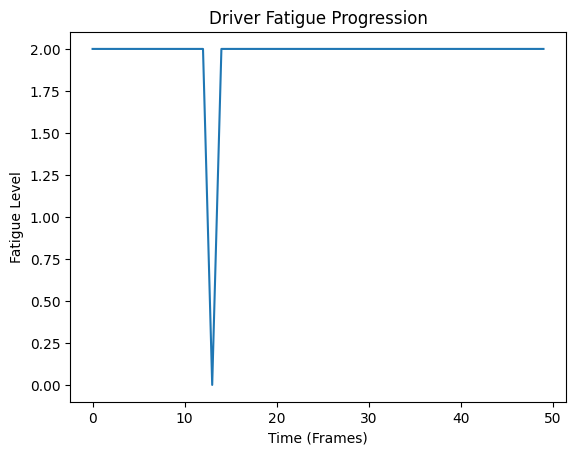

In [22]:
plt.plot(fatigue_predictions[:50])  # first 50 frames
plt.xlabel("Time (Frames)")
plt.ylabel("Fatigue Level")
plt.title("Driver Fatigue Progression")
plt.show()

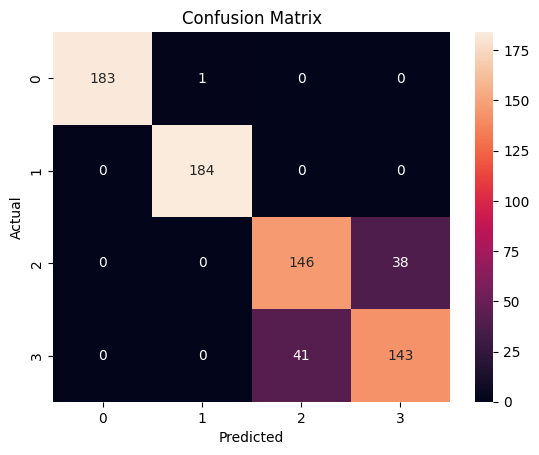

              precision    recall  f1-score   support

      Closed       1.00      0.99      1.00       184
        Open       0.99      1.00      1.00       184
     no_yawn       0.78      0.79      0.79       184
        yawn       0.79      0.78      0.78       184

    accuracy                           0.89       736
   macro avg       0.89      0.89      0.89       736
weighted avg       0.89      0.89      0.89       736



In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=test_data.class_indices.keys()
))

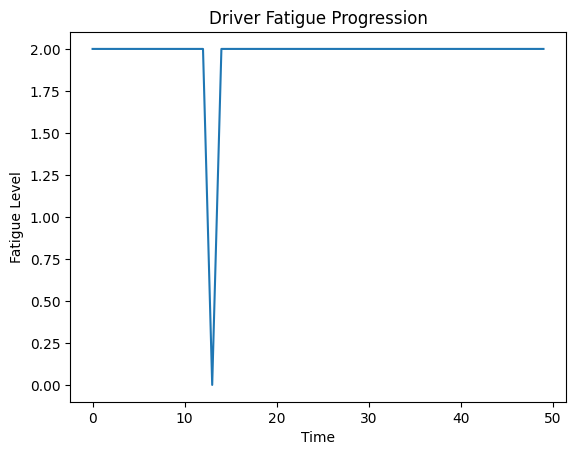

In [24]:
plt.plot(fatigue_predictions[:50])
plt.xlabel("Time")
plt.ylabel("Fatigue Level")
plt.title("Driver Fatigue Progression")
plt.show()